In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px

print("Everything is working!")

Everything is working!


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [5]:
import pandas as pd

fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

fund_master.head()


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [6]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folios = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

## NEV TREND ANALYSIS

In [ ]:
# Convert Date
nav["date"] = pd.to_datetime(
    nav["date"]
)

#Plot Chart
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()


fig.write_image(
    "charts/nav_trend.png"
)

## AUM GROWTH

FileNotFoundError: [Errno 2] No such file or directory: 'charts/aum_growth.png'

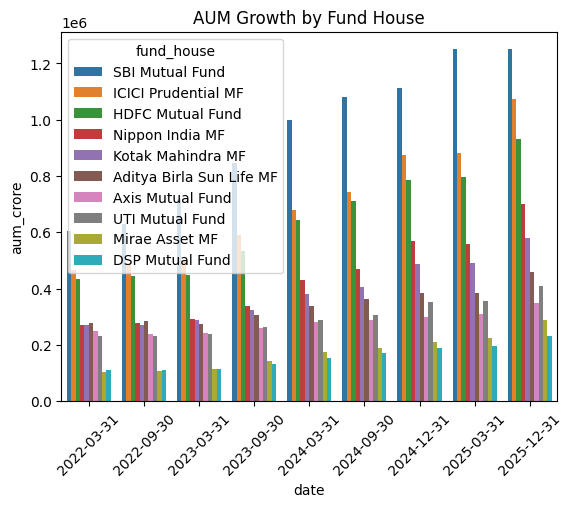

In [18]:
sns.barplot(
    data=aum,
    x="date",
    y="aum_crore",
    hue="fund_house"
)

plt.xticks(rotation=45)

plt.title("AUM Growth by Fund House")

plt.savefig(
    "charts/aum_growth.png"
)

plt.show()

## SIP TREND

In [19]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend"
)

fig.show()


fig.write_image(
    "charts/sip_trend.png"
)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


### Finding 3
Monthly SIP inflows increased significantly over time, indicating rising retail participation.

## CATEGORY HEATMAP

FileNotFoundError: [Errno 2] No such file or directory: 'charts/category_heatmap.png'

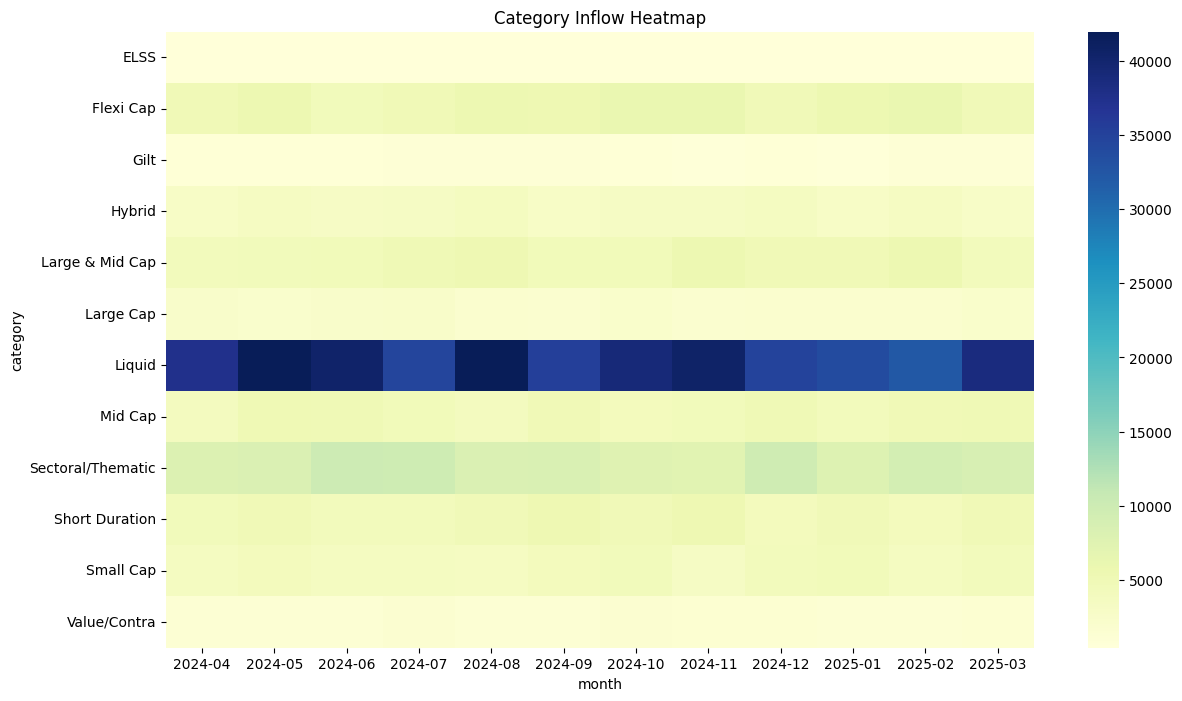

In [20]:
pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title(
    "Category Inflow Heatmap"
)

plt.savefig(
    "charts/category_heatmap.png"
)

plt.show()

## INVESTOR DEMOGRAPHICS

FileNotFoundError: [Errno 2] No such file or directory: 'charts/age_group_pie.png'

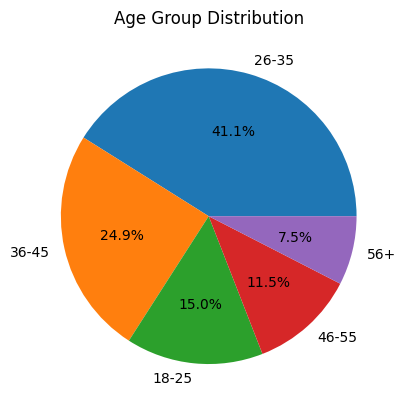

In [21]:
## Age group pie chart
transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title(
    "Age Group Distribution"
)

plt.savefig(
    "charts/age_group_pie.png"
)

plt.show()



FileNotFoundError: [Errno 2] No such file or directory: 'charts/gender_split.png'

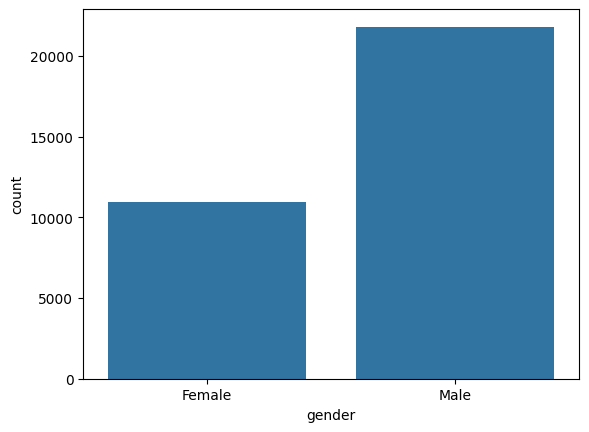

In [22]:
# Gender Split
sns.countplot(
    data=transactions,
    x="gender"
)

plt.savefig(
    "charts/gender_split.png"
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'charts/sip_boxplot.png'

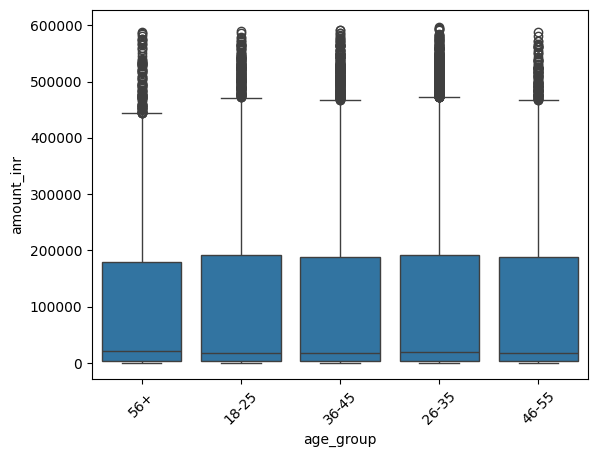

In [23]:
#SIP Boxplot
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)

plt.savefig(
    "charts/sip_boxplot.png"
)

plt.show()

## GEOGRAPHIC DISTRIBUTION

FileNotFoundError: [Errno 2] No such file or directory: 'charts/state_investment.png'

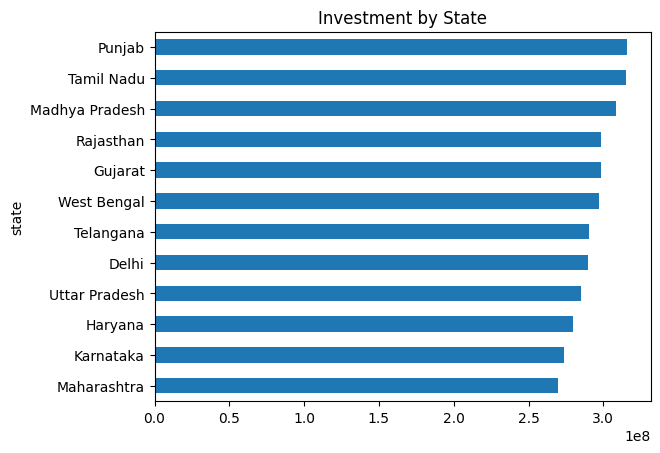

In [26]:
state_data = transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()

state_data.plot.barh()

plt.title(
    "Investment by State"
)

plt.savefig(
    "charts/state_investment.png"
)

plt.show()

## FOLIO GROWTH

FileNotFoundError: [Errno 2] No such file or directory: 'charts/folio_growth.png'

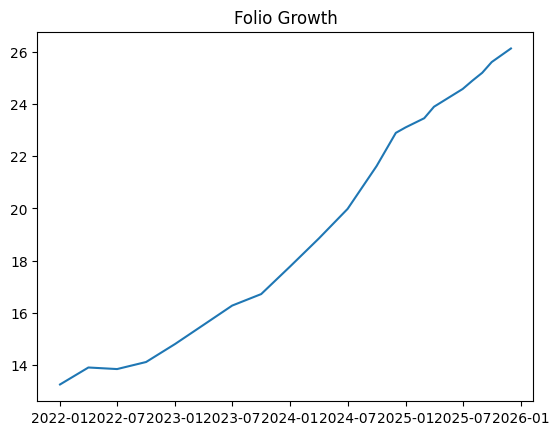

In [25]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title(
    "Folio Growth"
)

plt.savefig(
    "charts/folio_growth.png"
)

plt.show()

## CORRELATION MATRIX

FileNotFoundError: [Errno 2] No such file or directory: 'charts/correlation_matrix.png'

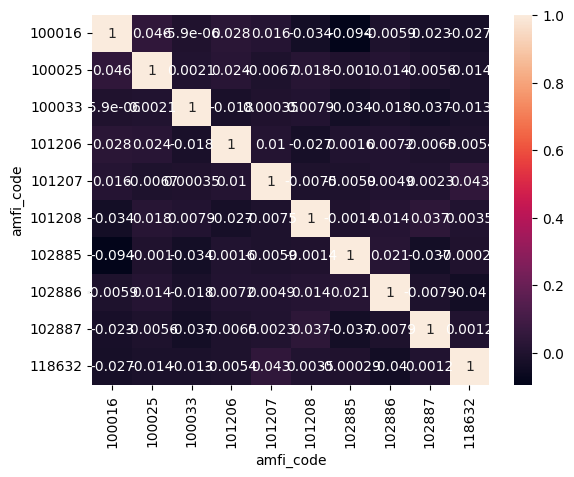

In [28]:
sample_funds = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]

pivot = sample_funds.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

sns.heatmap(
    corr,
    annot=True
)

plt.savefig(
    "charts/correlation_matrix.png"
)

plt.show()


## SECTOR ALLOCATION DONUT

FileNotFoundError: [Errno 2] No such file or directory: 'charts/sector_allocation.png'

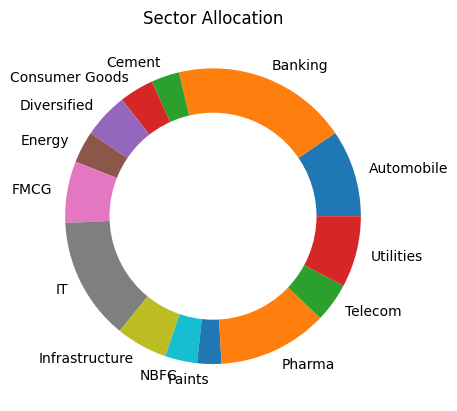

In [29]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

plt.pie(
    sector,
    labels=sector.index
)

centre = plt.Circle(
    (0,0),
    0.7,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre
)

plt.title(
    "Sector Allocation"
)

plt.savefig(
    "charts/sector_allocation.png"
)

plt.show()

Finding 1:
NAV values generally increased between 2022 and 2025.

Finding 2:
SBI Mutual Fund maintained the highest AUM.

Finding 3:
Retail SIP participation increased steadily.

Finding 4:
Large Cap and Flexi Cap categories attracted the highest inflows.

Finding 5:
Investors aged 26–35 formed the largest investor segment.

Finding 6:
Maharashtra contributed the highest investment volume.

Finding 7:
Industry folios nearly doubled during the study period.

Finding 8:
Most equity funds showed strong positive return correlation.

Finding 9:
Financial Services was the dominant portfolio sector.

Finding 10:
Expense ratios remained within regulatory norms.